# VibrationAnalyzer demo - Accelerometer noise data

This demo analysis will demonstrate how to use the `VibrationAnalyzer` class in detanalysis to analyze accelerometer continuous data.

The VibrationAnalyzer class contains special functions for calculating and visualizing differential **transfer functions** between accelerometer channels using various estimator methods.

Acquire the raw accelerometer data by collecting continuous data with the daq on an accelerometer channel.

### Overall workflow:

Initialize `VibrationAnalyzer(data_type='continuous')` -> `calc_psd()` -> `calc_transfer_function()`

---
## Setup

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pickle

from detanalysis import Vibration_Analyzer

## Parameters

In [ ]:
# ================================================
#                  Raw data path
# ================================================

dataset_name = 'continuous_I2_D20260622_T221858'
raw_path = f'/sdata1/runs/run73/raw/{dataset_name}'

series = 'I2_D20260622_T221904' # THIS IS OPTIONAL



# ================================================
#              Channel configuration
# ================================================

# Accelerometer channels to process
channels = ['AccelerometerGround', 'AccelerometerStage1', 'AccelerometerStage2']

# Channel pairs for transfer function computation formated as [output, input]:
# VibrationAnalyzer can compute the transfer function for multiple channel pairs at once.
channel_pairs = [
    ['AccelerometerStage1', 'AccelerometerGround'],    # Stage1 / Ground
    ['AccelerometerStage2', 'AccelerometerStage1'],    # Stage2 / Stage1
    ['AccelerometerStage2', 'AccelerometerGround'],    # Stage2 / Ground (overall transfer function)
]

# Accelerometer gain (ADC -> g conversion factor)
accel_gain = 100.0


# ================================================
#                 Data Configuration
# ================================================

trace_length_msec = 200


---
## Initialize VibrationAnalyzer

In [ ]:
# ================================================
#          Initialize VibrationAnalyzer
# ================================================

analyzer = Vibration_Analyzer(
    paths=raw_path,
    data_type='continuous',
    series=series,      # OPTIONAL, ONLY DEFINE IF YOU ONLY WANT TO PROCESS A SINGLE SERIES
)

---
## Acceleration PSD

In [ ]:
# ================================================
#                 Calculate PSDs
# ================================================

psd, variance, freqs = analyzer.calc_psd(
    channels=channels,
    accel_gain=accel_gain,
    trace_length_msec=trace_length_msec,
    verbose=True,
)

INFO: Building file map for raw data group continuous_I2_D20260622_T221858
Processing 20 events.


Processing continuous data events: 100%|███████████| 20/20 [01:01<00:00,  3.05s/it]

Rechunked into 6000 trace(s) of 100000 samples (0 trailing sample(s) discarded).


Text(0.5, 1.0, 'RMS Acceleration')

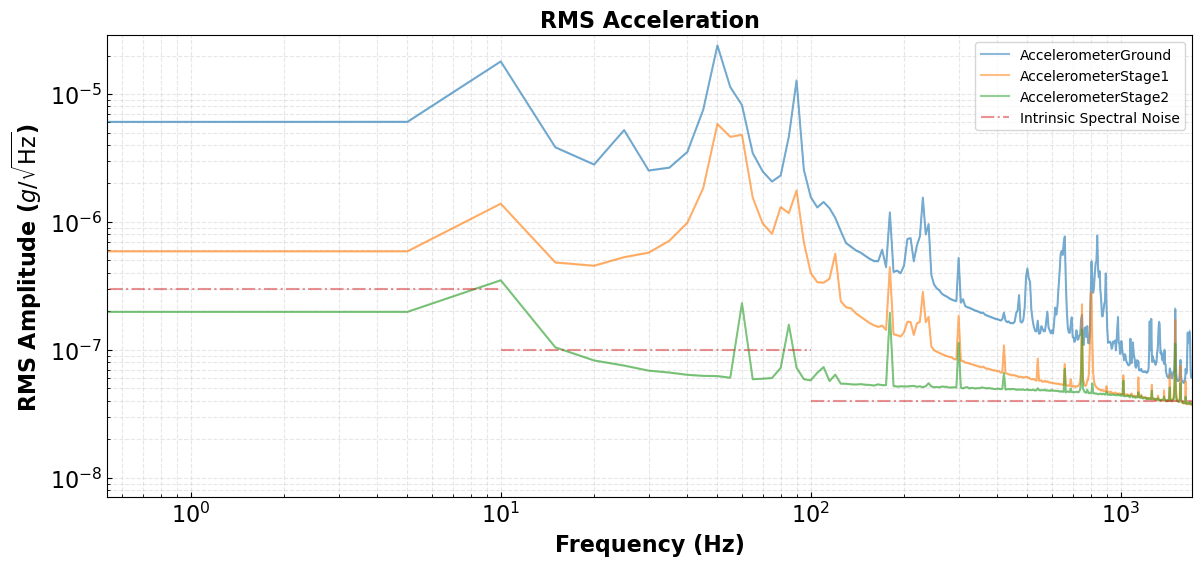

In [ ]:
# ================================================
#                 Plot PSDs
# ================================================

fig, ax = analyzer.plot_psd(
    # ALL OF THESE ARGUMENTS ARE OPTIONAL AND CAN BE LEFT OUT.
    # Showing so you know they exist:
    channels=channels,
    show_err=True,
    show_spectral_noise=True,
    spectral_noise_dict={ # FOLLOWING IS FOR PIEZOTRONICS 393B04. IT IS ALSO THE DEFAULT.
        'freqs_hz': np.array([0.1, 10.0, 100.0, 1000.0]),
        'noise_floor_g_per_sqrt_hz': np.array([0.3, 0.10, 0.04, 0.04])*1e-6
    },
)

ax.set_xlim(right=1700)
ax.set_title('RMS Acceleration', fontsize=16, fontweight='bold')

---
## Transfer Function

Vibration Analyzer supports multiple transfer function esiimator methods.

You can specify `methods = 'rms-ratio'` or `methods = 'cross-correlation'` to plot a single estimator, or `methods = ['rms-ratio', 'cross-correlation']` (or `methods = 'all'`) to overlay multiple estimators on the same plot.

It also supports plotting multiple channel pairs (differentials measured between 2 channels).

For extremeley large datasets, use log_downsample=True to reduce the number of points plotted visually.

In [ ]:
# ================================================
#          Calculate Transfer Functions
# ================================================

# Continuous data supports the 'rms_ratio' and 'cross_correlation' estimators.
analyzer.calc_transfer_function(
    channel_pairs=channel_pairs,
    methods=['rms_ratio', 'cross_correlation'],
    accel_gain=accel_gain,
    trace_length_msec=trace_length_msec,
)

{'rms-ratio': {('AccelerometerStage1',
   'AccelerometerGround'): {'channel_output': 'AccelerometerStage1', 'channel_input': 'AccelerometerGround', 'transfer_function': array([0.51408385, 0.09713477, 0.07719372, ..., 0.9743261 , 0.97383881,
          0.95782453]), 'transfer_sigma': array([0.00486197, 0.00100548, 0.00069027, ..., 0.00887511, 0.00886695,
          0.0124667 ]), 'freqs': array([0.00000e+00, 5.00000e+00, 1.00000e+01, ..., 2.49990e+05,
          2.49995e+05, 2.50000e+05]), 'method': 'rms-ratio'},
  ('AccelerometerStage2',
   'AccelerometerStage1'): {'channel_output': 'AccelerometerStage2', 'channel_input': 'AccelerometerStage1', 'transfer_function': array([0.09594748, 0.33626986, 0.25189326, ..., 0.95443096, 0.94805924,
          0.97216853]), 'transfer_sigma': array([0.00089176, 0.00334034, 0.00226021, ..., 0.00871001, 0.00868225,
          0.01283174]), 'freqs': array([0.00000e+00, 5.00000e+00, 1.00000e+01, ..., 2.49990e+05,
          2.49995e+05, 2.50000e+05]), 'method':

(2.9108612459802305, 1700)

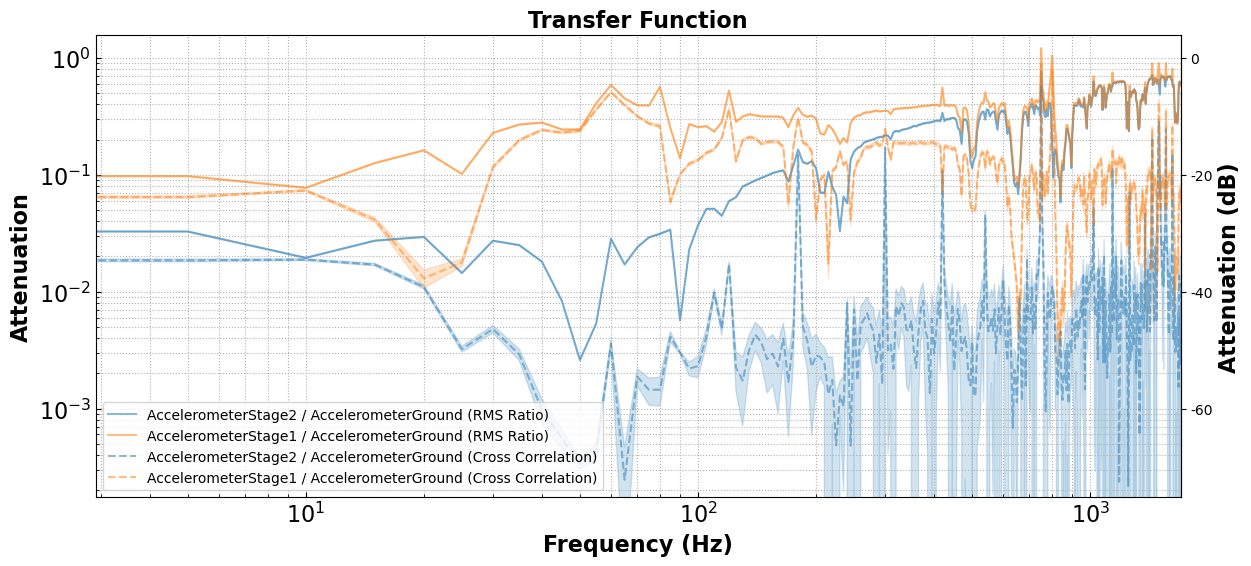

In [ ]:
# ================================================
#             Plot Transfer Functions
# ================================================
# MUST first call calc_transfer_function()
# This will cache the results in the object for plotting.

fig, ax = analyzer.plot_transfer_function(
    channel_pairs=[ # defines which differential transfer functions to plot
        ['AccelerometerStage2', 'AccelerometerGround'], 
        ['AccelerometerStage1', 'AccelerometerGround']
    ],
    methods=['rms-ratio', 'cross-correlation'], # 'rms-ratio', 'cross-correlation', 'all' strings are accepted, or list of multiple methods
    log_downsample=True,
)

ax.set_title('Transfer Function', fontsize=16, fontweight='bold')
ax.set_xlim(right=1700)